<a href="https://colab.research.google.com/github/DeepanshuSharma1607/ipl-winner-pedictor/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2094]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IPL_ball_by_ball_updated.csv"

# Load the latest version
df_nn = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print("First 5 records:", df__.head())

/tmp/ipykernel_1706/2934442778.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_nn = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [2095]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
# Set the path to the file you'd like to load
file_path = "deliveries_updated_ipl_upto_2025.csv"

# Load the latest version
df_mm = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_1706/3183163287.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_mm = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [2096]:
import pandas as pd
import numpy as np

# 1. Safely create 'season' without the strict format argument (prevents Pandas version errors)
df_mm['date'] = pd.to_datetime(df_mm['date'], errors='coerce')
df_mm['season'] = df_mm['date'].dt.year

# 2. Filter for 2024 and 2025
df_new = df_mm[df_mm['season'].isin([2024, 2025])].copy()

# 3. Drop existing 'over' and 'ball' columns to avoid duplicates when renaming
if 'over' in df_new.columns:
    df_new = df_new.drop(columns=['over', 'ball'])

# 4. Rename columns to match df_nn
mapping = {
    'matchId': 'match_id',
    'inning': 'innings',
    'over_ball': 'ball',
    'batsman': 'striker',
    'batsman_runs': 'runs_off_bat',
    'dismissal_kind': 'wicket_type',
    'date': 'start_date',
    'isWide': 'wides',
    'isNoBall': 'noballs',
    'Byes': 'byes',
    'LegByes': 'legbyes',
    'Penalty': 'penalty'
}
df_new = df_new.rename(columns=mapping)

# 5. ALIGN COLUMNS SAFELY: This fixes the missing 'venue' error automatically
df_new = df_new.reindex(columns=df_nn.columns)

# 6. Merge the historical df_nn with the new 24/25 data
df_nn_combined = pd.concat([df_nn, df_new], ignore_index=True)

print("Old shape:", df_nn.shape)
print("New combined shape:", df_nn_combined.shape)

Old shape: (243815, 22)
New combined shape: (278203, 22)


In [2097]:
print(df_nn_combined.head(10))

   match_id  season  start_date                  venue  innings  ball  \
0    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.1   
1    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.2   
2    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.3   
3    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.4   
4    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.5   
5    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.6   
6    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.7   
7    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.1   
8    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.2   
9    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.3   

            batting_team                 bowling_team      striker  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   SC Ganguly   
1  Kolkata Knight Riders  Royal Challengers Bangalore  B

In [2098]:
# df_matches.shape

In [2099]:
df_nn_combined.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [2100]:
df_nn_combined.shape

(278203, 22)

In [2101]:
df_nn_combined.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,34388
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [2102]:

df=df_nn_combined.copy()

In [2103]:
team_mapping = {
    # Rebranded Teams
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',

    # Successor Franchises (Optional but recommended for model logic)
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Pune Warriors': 'Rising Pune Supergiant'
}

# Apply to both team columns
df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)


In [2104]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278198,1473511,2025,2025-06-03 00:00:00,NaN,2,19.2,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278199,1473511,2025,2025-06-03 00:00:00,NaN,2,19.3,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278200,1473511,2025,2025-06-03 00:00:00,NaN,2,19.4,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278201,1473511,2025,2025-06-03 00:00:00,NaN,2,19.5,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2105]:
df.shape

(278203, 22)

In [2106]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278198,1473511,2025,2025-06-03 00:00:00,NaN,2,19.2,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278199,1473511,2025,2025-06-03 00:00:00,NaN,2,19.3,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278200,1473511,2025,2025-06-03 00:00:00,NaN,2,19.4,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278201,1473511,2025,2025-06-03 00:00:00,NaN,2,19.5,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2107]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [2108]:
print(df[['runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed']])

        runs_off_bat  extras  wides  noballs  byes  legbyes  penalty  \
0                  0       1    NaN      NaN   NaN      1.0      NaN   
1                  0       0    NaN      NaN   NaN      NaN      NaN   
2                  0       1    1.0      NaN   NaN      NaN      NaN   
3                  0       0    NaN      NaN   NaN      NaN      NaN   
4                  0       0    NaN      NaN   NaN      NaN      NaN   
...              ...     ...    ...      ...   ...      ...      ...   
278198             0       0    NaN      NaN   NaN      NaN      NaN   
278199             6       0    NaN      NaN   NaN      NaN      NaN   
278200             4       0    NaN      NaN   NaN      NaN      NaN   
278201             6       0    NaN      NaN   NaN      NaN      NaN   
278202             6       0    NaN      NaN   NaN      NaN      NaN   

       wicket_type player_dismissed  other_wicket_type  other_player_dismissed  
0              NaN              NaN                NaN

In [2109]:
cols_to_fix = ['runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_off_bat'] + df['extras']
total_score = df.groupby(['match_id', 'innings', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [2110]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [2111]:
df['first_innings_runs'] = np.where(df['innings'] == 1, df['team_runs'], 0)

df['second_innings_runs'] = np.where(df['innings'] == 2, df['team_runs'], 0)

In [2112]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1.0,0.0,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,1.0,1.0,0.0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,1,1.0,1.0,0.0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278198,1473511,2025,2025-06-03 00:00:00,NaN,2,19.2,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,0.0,NaN,NaN,NaN,NaN,0,162.0,0.0,162.0
278199,1473511,2025,2025-06-03 00:00:00,NaN,2,19.3,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,0.0,NaN,NaN,NaN,NaN,6,162.0,0.0,162.0
278200,1473511,2025,2025-06-03 00:00:00,NaN,2,19.4,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,0.0,NaN,NaN,NaN,NaN,4,168.0,0.0,168.0
278201,1473511,2025,2025-06-03 00:00:00,NaN,2,19.5,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,0.0,NaN,NaN,NaN,NaN,6,172.0,0.0,172.0


In [2113]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [2114]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket'],
      dtype='object')

In [2115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278203 entries, 0 to 278202
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                278203 non-null  int64  
 1   season                  278203 non-null  int64  
 2   start_date              278203 non-null  object 
 3   venue                   243815 non-null  object 
 4   innings                 278203 non-null  int64  
 5   ball                    278203 non-null  float64
 6   batting_team            278203 non-null  object 
 7   bowling_team            278203 non-null  object 
 8   striker                 278203 non-null  object 
 9   non_striker             278203 non-null  object 
 10  bowler                  278203 non-null  object 
 11  runs_off_bat            278203 non-null  int64  
 12  extras                  278203 non-null  int64  
 13  wides                   278203 non-null  float64
 14  noballs             

In [2116]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,0.0,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0,0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,1.0,1.0,0.0,0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,1,1.0,1.0,0.0,0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0,0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278198,1473511,2025,2025-06-03 00:00:00,NaN,2,19.2,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,NaN,NaN,NaN,NaN,0,162.0,0.0,162.0,0
278199,1473511,2025,2025-06-03 00:00:00,NaN,2,19.3,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,NaN,NaN,NaN,NaN,6,162.0,0.0,162.0,0
278200,1473511,2025,2025-06-03 00:00:00,NaN,2,19.4,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,NaN,NaN,NaN,NaN,4,168.0,0.0,168.0,0
278201,1473511,2025,2025-06-03 00:00:00,NaN,2,19.5,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,0.0,NaN,NaN,NaN,NaN,6,172.0,0.0,172.0,0


In [2117]:
final_scores = df[df['innings'] == 1].groupby('match_id')['team_runs'].max()
df = df.merge(final_scores.rename('target'), on='match_id')
df['target'] = np.where(df['innings'] == 2, df['target'] + 1, 0)

In [2118]:
df['over'] = df['ball'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = df['ball'].astype(str).str.split('.').str[1].astype(int)

In [2119]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over'] * 6 + df['ball_in_over']

In [2120]:
df['runs_to_win'] = np.where(
    df['innings'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [2121]:
df['runs_to_win'] = np.where(
    df['innings'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [2122]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)


In [2123]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [2124]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [2125]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [2126]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['innings'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [2127]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled']

In [2128]:
df['total_wickets'] = df.groupby(['match_id','innings'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','innings'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [2129]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,over,ball_in_over,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,0,1,1,0.0,0.000000,0.0,0.000000,119,0.0,10.0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,2,2,0.0,3.000000,0.0,0.000000,118,0.0,10.0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,3,3,0.0,2.000000,0.0,0.000000,117,0.0,10.0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,4,4,0.0,3.000000,0.0,0.000000,116,0.0,10.0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,5,5,0.0,2.400000,0.0,0.000000,115,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278198,1473511,2025,2025-06-03 00:00:00,NaN,2,19.2,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,19,2,116,29.0,8.379310,36.0,0.232759,4,7.0,3.0
278199,1473511,2025,2025-06-03 00:00:00,NaN,2,19.3,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,19,3,117,29.0,8.307692,36.0,0.230769,3,7.0,3.0
278200,1473511,2025,2025-06-03 00:00:00,NaN,2,19.4,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,19,4,118,23.0,8.542373,36.0,0.237288,2,7.0,3.0
278201,1473511,2025,2025-06-03 00:00:00,NaN,2,19.5,Punjab Kings,Royal Challengers Bengaluru,Shashank Singh,KA Jamieson,...,19,5,119,19.0,8.672269,36.0,0.240896,1,7.0,3.0


In [2130]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining'],
      dtype='object')

In [2131]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wides'] == 0).astype(int)

# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['runs_off_bat'].cumsum()
# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['batsman_run_cum'].shift(1).fillna(0)

# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['valid_ball'].cumsum()
# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['balls_faced_cum'].shift(1).fillna(0)

# df['match_strike_rate'] = np.where(
#     df['balls_faced_cum'] == 0,
#     0,
#     (df['batsman_run_cum'] / df['balls_faced_cum']) * 100
# )



# df['batsman_run_cum_career'] = df.groupby('striker')['runs_off_bat'].cumsum()
# df['batsman_run_cum_career'] = df.groupby('striker')['batsman_run_cum_career'].shift(1).fillna(0)

# df['balls_faced_cum_career'] = df.groupby('striker')['valid_ball'].cumsum()
# df['balls_faced_cum_career'] = df.groupby('striker')['balls_faced_cum_career'].shift(1).fillna(0)

# df['batsman_outs_career'] = df.groupby('striker')['is_out'].cumsum()
# df['batsman_outs_career'] = df.groupby('striker')['batsman_outs_career'].shift(1).fillna(0)

# universal_runs = 50
# universal_outs = 2

# df['batting_average'] = (
#     df['batsman_run_cum_career'] + universal_runs
# ) / (
#     df['batsman_outs_career'] + universal_outs
# )


# universal_sr_runs = 100
# universal_balls = 80

# df['career_strike_rate'] = (
#     (df['batsman_run_cum_career'] + universal_sr_runs) /
#     (df['balls_faced_cum_career'] + universal_balls)
# ) * 100
# Aggregate per striker per season
season_bat = df.groupby(['season', 'striker']).agg(
    season_runs=('runs_off_bat', 'sum'),
    season_balls=('valid_ball', 'sum'),
    season_outs=('is_out', 'sum')
).reset_index().sort_values(['striker', 'season'])

# Cumsum then shift — so current season stats NOT included
season_bat['career_runs'] = season_bat.groupby('striker')['season_runs'].cumsum().shift(1).fillna(0)
season_bat['career_balls'] = season_bat.groupby('striker')['season_balls'].cumsum().shift(1).fillna(0)
season_bat['career_outs'] = season_bat.groupby('striker')['season_outs'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bat['batting_average'] = (season_bat['career_runs'] + 50) / (season_bat['career_outs'] + 2)
season_bat['career_strike_rate'] = ((season_bat['career_runs'] + 100) / (season_bat['career_balls'] + 80)) * 100

# Merge back
df = df.merge(
    season_bat[['season', 'striker', 'batting_average', 'career_strike_rate']],
    on=['season', 'striker'], how='left'
)

In [2132]:


# df['bowler_runs_conceded'] = df.groupby('bowler')['runs_off_bat'].cumsum()
# df['bowler_runs_conceded'] = df.groupby('bowler')['bowler_runs_conceded'].shift(1).fillna(0)

# df['bowler_balls_bowled'] = df.groupby('bowler')['valid_ball'].cumsum()
# df['bowler_balls_bowled'] = df.groupby('bowler')['bowler_balls_bowled'].shift(1).fillna(0)

# df['bowler_wickets_cum'] = df.groupby('bowler')['is_wicket'].cumsum()
# df['bowler_wickets_cum'] = df.groupby('bowler')['bowler_wickets_cum'].shift(1).fillna(0)



# universal_runs_conceded = 300
# universal_balls = 240
# universal_wickets = 10


# df['exp_bowler_eco'] = (
#     (df['bowler_runs_conceded'] + universal_runs_conceded) /
#     (df['bowler_balls_bowled'] + universal_balls)
# ) * 6


# df['exp_bowler_avg'] = (
#     df['bowler_runs_conceded'] + universal_runs_conceded
# ) / (
#     df['bowler_wickets_cum'] + universal_wickets
# )
# Aggregate per bowler per season
season_bowl = df.groupby(['season', 'bowler']).agg(
    season_runs_c=('runs_off_bat', 'sum'),
    season_balls_b=('valid_ball', 'sum'),
    season_wkts=('is_wicket', 'sum')
).reset_index().sort_values(['bowler', 'season'])

# Cumsum then shift — so current season NOT included
season_bowl['career_runs_c'] = season_bowl.groupby('bowler')['season_runs_c'].cumsum().shift(1).fillna(0)
season_bowl['career_balls_b'] = season_bowl.groupby('bowler')['season_balls_b'].cumsum().shift(1).fillna(0)
season_bowl['career_wkts'] = season_bowl.groupby('bowler')['season_wkts'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bowl['exp_bowler_eco'] = ((season_bowl['career_runs_c'] + 300) / (season_bowl['career_balls_b'] + 240)) * 6
season_bowl['exp_bowler_avg'] = (season_bowl['career_runs_c'] + 300) / (season_bowl['career_wkts'] + 10)

# Merge back
df = df.merge(
    season_bowl[['season', 'bowler', 'exp_bowler_eco', 'exp_bowler_avg']],
    on=['season', 'bowler'], how='left'
)

In [2133]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batting_average',
       'career_strike_rate', 'exp_bowler_eco', 'exp_bowler_avg'],
      dtype='object')

In [2134]:
df.shape

(278203, 44)

In [2135]:
final_scores = df.groupby(['match_id', 'innings'])['team_runs'].max().reset_index()
final_scores = final_scores.pivot(index='match_id', columns='innings', values='team_runs').reset_index()
final_scores['winner_innings'] = np.where(
    final_scores[2] > final_scores[1], 2,
    np.where(final_scores[2] < final_scores[1], 1, 0)
)

df = df.merge(final_scores[['match_id', 'winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['innings'] == 2) & (df['winner_innings'] == 2),
    1,
    np.where(
        (df['innings'] == 2) & (df['winner_innings'] == 1),
        0,
        -1   # tie
    )
)

In [2136]:
df['match_phase'] = pd.cut(df['over'],
                            bins=[-1, 5, 14, 19],
                            labels=[0, 1, 2]).astype(int)

In [2137]:
df['first_innings_total'] = df['target'] - 1

In [2138]:
df.shape

(278203, 48)

In [2139]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batting_average',
       'career_strike_rate', 'exp_bowler_eco', 'exp_bowler_avg',
       'winner_innings', 'result', 'match_phase', 'first_innings_total'],
      dtype='object')

In [2140]:
drop_list = [
    'match_id', 'start_date', 'runs_off_bat', 'extras', 'wides',
    'noballs', 'byes', 'legbyes', 'penalty', 'curr_ball_runs',
    'wicket_type', 'player_dismissed', 'other_wicket_type',
    'other_player_dismissed', 'is_wicket', 'is_out', 'winner_innings',
    'ball', 'over', 'ball_in_over', 'balls_bowled', 'valid_ball',
    'team_runs', 'first_innings_runs', 'second_innings_runs', 'target',
    # 'batsman_run_cum', 'balls_faced_cum',
    'total_wickets'
]
df = df.drop(columns=drop_list)

In [2141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278203 entries, 0 to 278202
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   season               278203 non-null  int64  
 1   venue                243815 non-null  object 
 2   innings              278203 non-null  int64  
 3   batting_team         278203 non-null  object 
 4   bowling_team         278203 non-null  object 
 5   striker              278203 non-null  object 
 6   non_striker          278203 non-null  object 
 7   bowler               278203 non-null  object 
 8   runs_to_win          278203 non-null  float64
 9   curr_run_rate        278203 non-null  float64
 10  req_run_rate         278203 non-null  float64
 11  crr_rrr_ratio        278203 non-null  float64
 12  balls_remaining      278203 non-null  int64  
 13  wickets_remaining    278203 non-null  float64
 14  batting_average      278203 non-null  float64
 15  career_strike_rat

In [2142]:
df['pressure'] = df['req_run_rate'] - df['curr_run_rate']

In [2143]:
df = df[df['innings'] <= 2]
df = df[df['result'] != -1]


In [2144]:
df.describe()

,season,innings,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,match_phase,first_innings_total,pressure
count,118631.000000,118631.0,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000,118631.000000
mean,2016.780437,2.0,96.398243,7.358980,10.501400,0.916069,62.651651,7.488279,27.939213,129.659723,7.581440,26.855496,0.274768,0.885266,169.585758,3.142420
std,5.246009,0.0,51.407017,2.358252,5.927830,0.904235,33.508355,2.179153,8.489375,12.861483,0.537289,4.987113,0.446399,0.719986,30.921883,6.367773
min,2008.000000,2.0,-15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000,0.000000,61.000000,-17.582609
25%,2012.000000,2.0,56.000000,6.200000,7.523810,0.525395,34.000000,6.000000,22.315789,121.686747,7.266833,23.195122,0.000000,0.000000,149.000000,-0.397487
50%,2017.000000,2.0,95.000000,7.500000,9.265823,0.759171,63.000000,8.000000,28.000000,128.448276,7.604061,26.121951,0.000000,1.000000,169.000000,2.225064
75%,2022.000000,2.0,134.000000,8.769231,11.550000,1.041667,92.000000,9.000000,32.907216,136.516854,7.933333,30.095238,1.000000,1.000000,189.000000,5.314286
max,2025.000000,2.0,286.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,194.570136,9.425287,45.312500,1.000000,2.000000,285.000000,31.565217


In [2145]:
df = df[df['innings'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [2146]:
df.describe()

,season,innings,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,match_phase,first_innings_total,pressure
count,117693.000000,117693.0,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000,117693.000000
mean,2016.780633,2.0,97.074499,7.350947,10.409520,0.922278,63.111026,7.513964,27.973450,129.688260,7.580446,26.854198,0.273338,0.876764,169.579882,3.058573
std,5.246823,0.0,51.021485,2.362626,5.647893,0.905085,33.229394,2.159021,8.479825,12.852067,0.537559,4.987972,0.445675,0.716244,30.922104,6.116005
min,2008.000000,2.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000,0.000000,61.000000,-17.582609
25%,2012.000000,2.0,57.000000,6.184615,7.531915,0.531674,35.000000,6.000000,22.363636,121.691678,7.266833,23.195122,0.000000,0.000000,149.000000,-0.381766
50%,2017.000000,2.0,96.000000,7.479452,9.258621,0.762821,64.000000,8.000000,28.000000,128.448276,7.602931,26.121951,0.000000,1.000000,169.000000,2.217391
75%,2022.000000,2.0,135.000000,8.769231,11.510204,1.044944,92.000000,9.000000,32.907216,136.597189,7.933333,30.095238,1.000000,1.000000,189.000000,5.266715
max,2025.000000,2.0,286.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,194.570136,9.425287,45.312500,1.000000,2.000000,285.000000,31.565217


In [2147]:
train = df[df['season'] <= 2021]
cv    = df[(df['season'] >= 2022) & (df['season'] <= 2023)]
test  = df[(df['season'] >= 2024) & (df['season'] <= 2025)]

In [2148]:
x_train = train.drop('result', axis=1)
y_train = train['result']

x_cv = cv.drop('result', axis=1)
y_cv = cv['result']

x_test = test.drop('result', axis=1)
y_test = test['result']

In [2149]:
print("Train:", train['season'].unique())
print("CV:", cv['season'].unique())
print("Test:", test['season'].unique())

Train: [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021]
CV: [2022 2023]
Test: [2024 2025]


In [2150]:
x_train = x_train.drop(columns=['season'])
x_cv = x_cv.drop(columns=['season'])
x_test = x_test.drop(columns=['season'])

In [2151]:
x_train = x_train.drop(columns=['innings'])
x_cv = x_cv.drop(columns=['innings'])
x_test = x_test.drop(columns=['innings'])

In [2152]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87152 entries, 124 to 208039
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   venue                87152 non-null  object 
 1   batting_team         87152 non-null  object 
 2   bowling_team         87152 non-null  object 
 3   striker              87152 non-null  object 
 4   non_striker          87152 non-null  object 
 5   bowler               87152 non-null  object 
 6   runs_to_win          87152 non-null  float64
 7   curr_run_rate        87152 non-null  float64
 8   req_run_rate         87152 non-null  float64
 9   crr_rrr_ratio        87152 non-null  float64
 10  balls_remaining      87152 non-null  int64  
 11  wickets_remaining    87152 non-null  float64
 12  batting_average      87152 non-null  float64
 13  career_strike_rate   87152 non-null  float64
 14  exp_bowler_eco       87152 non-null  float64
 15  exp_bowler_avg       87152 non-null  f

In [2153]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
# target_encode=['striker','bowler','non_striker']
nominal_cols=['batting_team','bowling_team']#,'venue']
numeric_cols=['runs_to_win', 'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio',
              'balls_remaining', 'wickets_remaining',
              #'match_strike_rate',
              'batting_average','pressure','career_strike_rate','first_innings_total',
              'exp_bowler_eco', 'exp_bowler_avg']
print("Infinite values remaining:", np.isinf(df[numeric_cols]).values.sum())
preprocessing=ColumnTransformer(transformers=[
    ('nominal',OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),nominal_cols),
    # ('target',TargetEncoder(cv=5),target_encode),
    ('scalar',StandardScaler(),numeric_cols)
])


Infinite values remaining: 0


In [2154]:
pipe=make_pipeline(preprocessing,LogisticRegression(C=0.001, solver='liblinear', max_iter=1000))

In [2155]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team']),
                                                 ('scalar', StandardScaler(),
                                                  ['runs_to_win',
                                                   'curr_run_rate',
                                                   'req_run_rate',
                                                   'crr_rrr_ratio',
                                                   'balls_remaining',
                                                   'wickets_remaining',
                                                   'batting_average',
                                                   'pressure',
                                                   'career_strike_rate',
                                                   'first_innings_total',
                                                   'exp_bowler_eco',
                                                   'exp_bowler_avg'])])),
                ('logisticregression',
                 LogisticRegression(C=0.001, max_iter=1000,
                                    solver='liblinear'))])

In [2156]:
proba_cv=pipe.predict(x_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [2157]:
proba_train=pipe.predict(x_train)

In [2158]:
proba_test=pipe.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [2159]:
from sklearn.metrics import roc_auc_score,f1_score,accuracy_score
print(accuracy_score(proba_train,y_train))
print(accuracy_score(proba_cv,y_cv))
print(accuracy_score(proba_test,y_test))

0.7396043693776391
0.809813962533221
0.733889109434961


In [2160]:
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler

overfit_cols = ['striker', 'non_striker', 'bowler', 'venue']

x_ttrain = x_train.drop(columns=overfit_cols)
x_ccv    = x_cv.drop(columns=overfit_cols)
x_ttest  = x_test.drop(columns=overfit_cols)

target_encode_modified = []

nominal_cols_modified = ['batting_team','bowling_team']

preprocessing_for_xgb = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), nominal_cols_modified),
    ('target', TargetEncoder(cv=5), target_encode_modified),
    ('scalar', StandardScaler(), numeric_cols)
])

xgb_pipe = make_pipeline(
    preprocessing_for_xgb,
    XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=5,
    reg_alpha=1,
    min_child_weight=10,
    gamma=1,
    eval_metric='logloss',
    random_state=69
    )
)

xgb_pipe.fit(x_ttrain, y_train)

print("Train:", accuracy_score(y_train, xgb_pipe.predict(x_ttrain)))
print("CV:   ", accuracy_score(y_cv,    xgb_pipe.predict(x_ccv)))
print("Test: ", accuracy_score(y_test,  xgb_pipe.predict(x_ttest)))

Train: 0.7922595006425556
CV:    0.8162312828158423
Test:  0.7459970887918487


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [2161]:
prob_ensemble = (0.65 * prob_xgb) + (0.35 * prob_lr)
pred_ensemble = (prob_ensemble >= 0.5).astype(int)
print("Weighted Ensemble:", accuracy_score(y_test, pred_ensemble))

Weighted Ensemble: 0.7493052798729655


In [2162]:
x_train.columns

Index(['venue', 'batting_team', 'bowling_team', 'striker', 'non_striker',
       'bowler', 'runs_to_win', 'curr_run_rate', 'req_run_rate',
       'crr_rrr_ratio', 'balls_remaining', 'wickets_remaining',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg', 'match_phase', 'first_innings_total', 'pressure'],
      dtype='object')

In [2163]:
x_ttrain.columns

Index(['batting_team', 'bowling_team', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'wickets_remaining',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg', 'match_phase', 'first_innings_total', 'pressure'],
      dtype='object')

In [2164]:
row = pd.DataFrame([{
    'batting_team': 'Kolkata Knight Riders',
    'bowling_team': 'Sunrisers Hyderabad',
    'runs_to_win': 107,
    'curr_run_rate': 11.08,
    'req_run_rate': 11.67,
    'crr_rrr_ratio': 0.95,
    'balls_remaining': 55,
    'wickets_remaining': 7,
    'batting_average': 27.0,
    'career_strike_rate': 135.0,
    'exp_bowler_eco': 7.5,
    'exp_bowler_avg': 25.0,
    'pressure': 11.67-11.08,
    'match_phase': 1,
    'first_innings_total': 226
}])

pred_xgb = xgb_pipe.predict(row)
pred_xgb_proba=xgb_pipe.predict_proba(row)
print(pred_xgb)
print(pred_xgb_proba)
if pred_xgb == 1:
  print(batting_team," will win the match")
else:
  print(bowling_team,' will win the match')

[0]
[[0.974384   0.02561601]]
Sunrisers Hyderabad  will win the match


In [2165]:
row = pd.DataFrame([{
    'batting_team': 'Kolkata Knight Riders',
    'bowling_team': 'Sunrisers Hyderabad',
    'runs_to_win': 107,
    'curr_run_rate': 11.08,
    'req_run_rate': 11.67,
    'crr_rrr_ratio': 0.95,
    'balls_remaining': 55,
    'wickets_remaining': 7,
    'batting_average': 27.0,
    'career_strike_rate': 135.0,
    'exp_bowler_eco': 7.5,
    'exp_bowler_avg': 25.0,
    'pressure': 11.67-11.08,
      'match_phase': 1,
    'first_innings_total': 226
}])


# prediction
print(pipe.predict(row))
print(pipe.predict_proba(row))

[0]
[[0.76955727 0.23044273]]


In [2166]:
row = pd.DataFrame([{
    'batting_team': 'Mumbai Indians',
    'bowling_team': 'Chennai Super Kings',
    'runs_to_win': 48,
    'curr_run_rate': 8.5,
    'req_run_rate': 9.6,
    'crr_rrr_ratio': 0.88,
    'balls_remaining': 30,
    'wickets_remaining': 7,
    'batting_average': 28,
    'career_strike_rate': 140,
    'exp_bowler_eco': 7.2,
    'exp_bowler_avg': 26,
    'pressure': 9.6-8.5,
    'first_innings_total':170,
    'match_phase':2,
}])
pred_xgb = xgb_pipe.predict(row)
pred_xgb_proba=xgb_pipe.predict_proba(row)
print(pred_xgb)
print(pred_xgb_proba)
if pred_xgb == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')

[0]
[[0.5987389  0.40126106]]
Chennai Super Kings will win the match


In [2167]:
row = pd.DataFrame([{
    'batting_team': 'Mumbai Indians',
    'bowling_team': 'Chennai Super Kings',
    'runs_to_win': 48,
    'curr_run_rate': 8.5,
    'req_run_rate': 9.6,
    'crr_rrr_ratio': 0.88,
    'balls_remaining': 30,
    'wickets_remaining': 7,
    'batting_average': 28,
    'career_strike_rate': 140,
    'exp_bowler_eco': 7.2,
    'exp_bowler_avg': 26,
    'pressure': 9.6-8.5,
    'first_innings_total':170,
    'match_phase':2
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')

[0]
[[0.60291007 0.39708993]]
Chennai Super Kings will win the match


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
   LOGISTIC REGRESSION
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  LR — Train
  Accuracy  : 0.7396
  Precision : 0.5967
  Recall    : 0.3026
  F1 Score  : 0.4016
  ROC-AUC   : 0.7818
  Log Loss  : 0.4957
  Brier     : 0.1666

  Classification Report:
                   precision    recall  f1-score   support

Bowling Team Wins       0.76      0.92      0.83     61989
Batting Team Wins       0.60      0.30      0.40     25163

         accuracy                           0.74     87152
        macro avg       0.68      0.61      0.62     87152
     weighted avg       0.72      0.74      0.71     87152


  LR — CV
  Accuracy  : 0.8098
  Precision : 0.4829
  Recall    : 0.2702
  F1 Score  : 0.3465
  ROC-AUC   : 0.7901
  Log Loss  : 0.4162
  Brier     : 0.1323

  Classification Report:
                   precision    recall  f1-score   support

Bowling Team Wins       0.85      0.93      0.89     12548
Batting Team Wins       0.48      0.2

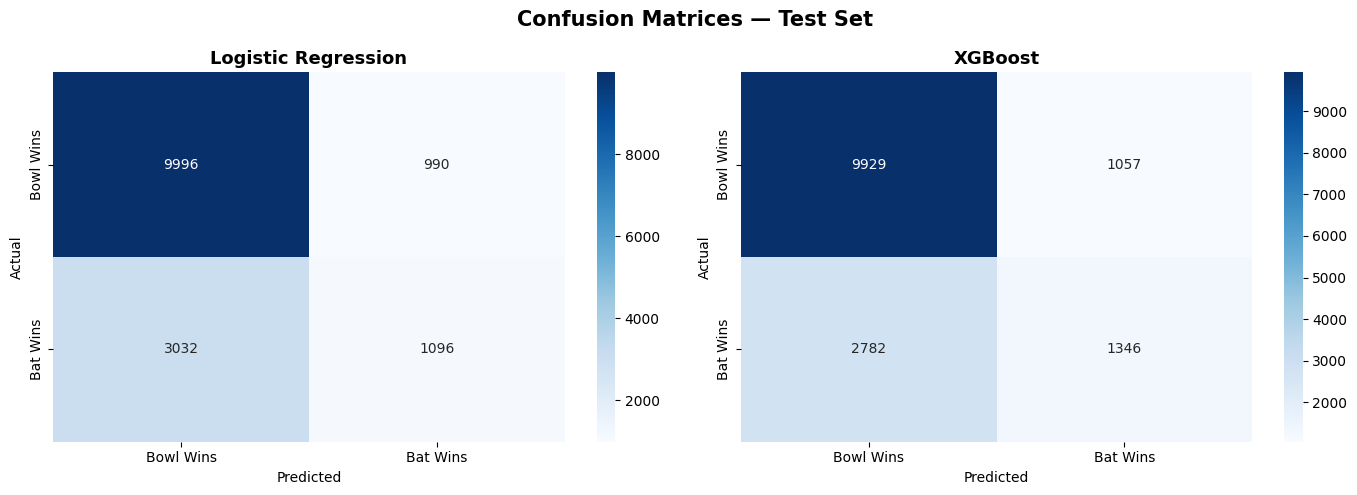

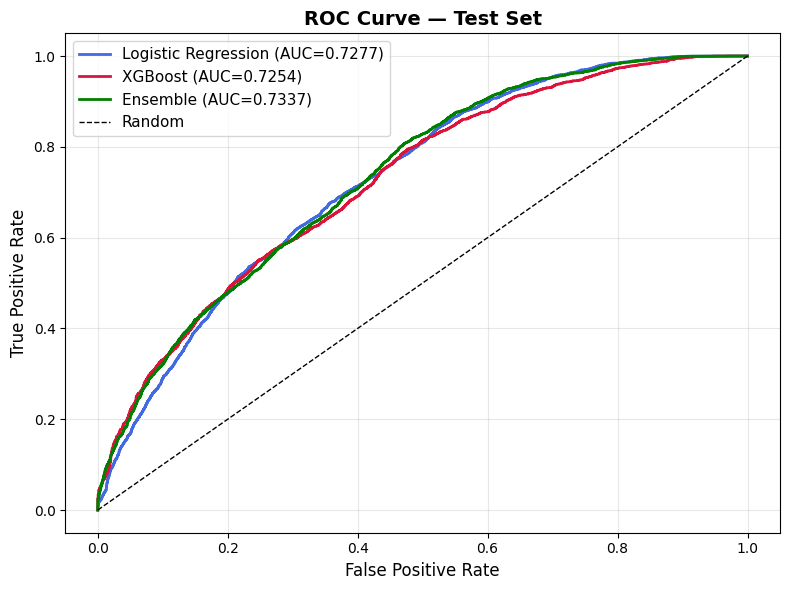

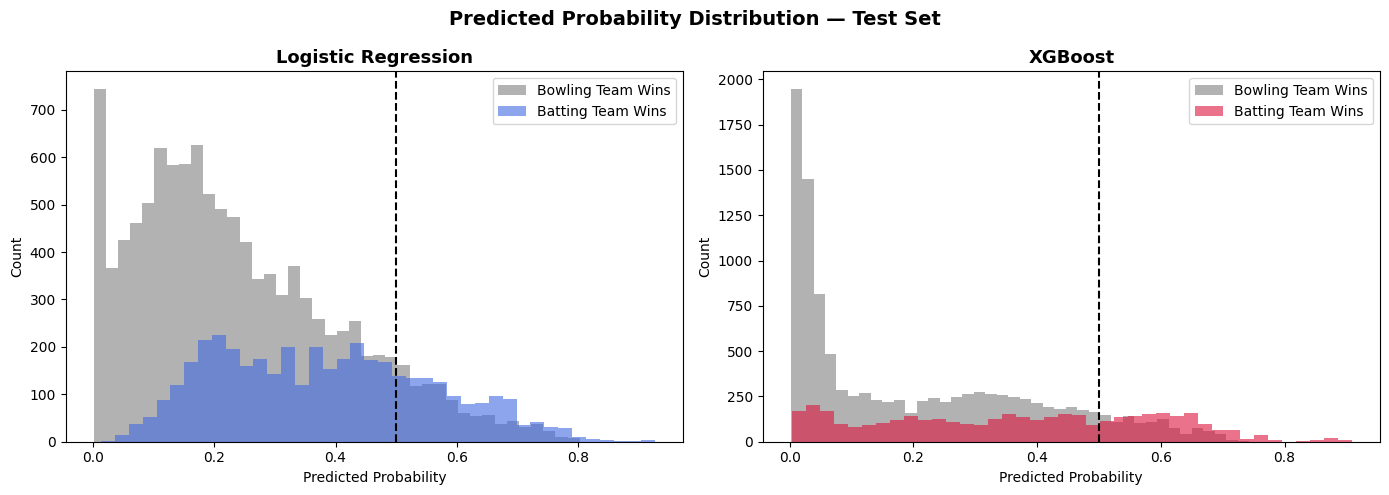

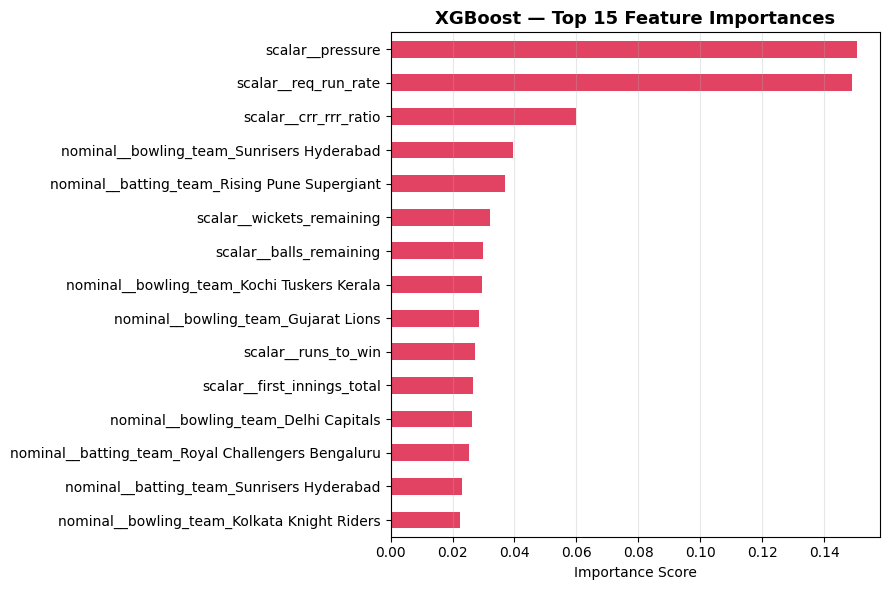


                     FINAL SUMMARY                     
Model                  Split       Acc     F1     AUC
-------------------------------------------------------
Logistic Regression    Train    0.7396 0.4016  0.7818
Logistic Regression    CV       0.8098 0.3465  0.7901
Logistic Regression    Test     0.7339 0.3528  0.7277
XGBoost                Train    0.7923 0.5524  0.8589
XGBoost                CV       0.8162 0.4100  0.7763
XGBoost                Test     0.7460 0.4122  0.7254
Ensemble (0.65/0.35)   Test     0.7453 0.3947  0.7337


In [2168]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, log_loss, brier_score_loss
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Probabilities ──────────────────────────────────────────
# Logistic Regression
lr_train_prob  = pipe.predict_proba(x_train)[:, 1]
lr_cv_prob     = pipe.predict_proba(x_cv)[:, 1]
lr_test_prob   = pipe.predict_proba(x_test)[:, 1]

lr_train_pred  = pipe.predict(x_train)
lr_cv_pred     = pipe.predict(x_cv)
lr_test_pred   = pipe.predict(x_test)

# XGBoost
xgb_train_prob = xgb_pipe.predict_proba(x_ttrain)[:, 1]
xgb_cv_prob    = xgb_pipe.predict_proba(x_ccv)[:, 1]
xgb_test_prob  = xgb_pipe.predict_proba(x_ttest)[:, 1]

xgb_train_pred = xgb_pipe.predict(x_ttrain)
xgb_cv_pred    = xgb_pipe.predict(x_ccv)
xgb_test_pred  = xgb_pipe.predict(x_ttest)

# ── Metrics Function ───────────────────────────────────────
def full_metrics(name, y_true, y_pred, y_prob):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Log Loss  : {log_loss(y_true, y_prob):.4f}")
    print(f"  Brier     : {brier_score_loss(y_true, y_prob):.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Bowling Team Wins',
                                               'Batting Team Wins']))

# ── Print All Metrics ──────────────────────────────────────
print("\n" + "★"*45)
print("   LOGISTIC REGRESSION")
print("★"*45)
full_metrics("LR — Train", y_train, lr_train_pred, lr_train_prob)
full_metrics("LR — CV",    y_cv,    lr_cv_pred,    lr_cv_prob)
full_metrics("LR — Test",  y_test,  lr_test_pred,  lr_test_prob)

print("\n\n" + "★"*45)
print("   XGBOOST")
print("★"*45)
full_metrics("XGB — Train", y_train, xgb_train_pred, xgb_train_prob)
full_metrics("XGB — CV",    y_cv,    xgb_cv_pred,    xgb_cv_prob)
full_metrics("XGB — Test",  y_test,  xgb_test_pred,  xgb_test_prob)

# ── Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [lr_test_pred, xgb_test_pred],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bowl Wins', 'Bat Wins'],
                yticklabels=['Bowl Wins', 'Bat Wins'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ── ROC Curves ────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for probs, name, color in [
    (lr_test_prob,  'Logistic Regression', 'royalblue'),
    (xgb_test_prob, 'XGBoost',             'crimson'),
    ((0.65*xgb_test_prob + 0.35*lr_test_prob), 'Ensemble', 'green')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Probability Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted Probability Distribution — Test Set',
             fontsize=14, fontweight='bold')

for ax, probs, title, color in zip(
    axes,
    [lr_test_prob, xgb_test_prob],
    ['Logistic Regression', 'XGBoost'],
    ['royalblue', 'crimson']
):
    ax.hist(probs[y_test==0], bins=40, alpha=0.6,
            label='Bowling Team Wins', color='gray')
    ax.hist(probs[y_test==1], bins=40, alpha=0.6,
            label='Batting Team Wins', color=color)
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# ── XGB Feature Importance ────────────────────────────────
xgb_model    = xgb_pipe.named_steps['xgbclassifier']
feature_names = xgb_pipe.named_steps['columntransformer']\
                         .get_feature_names_out()

importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', ax=ax, color='crimson', alpha=0.8)
ax.set_title('XGBoost — Top 15 Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Final Summary Table ────────────────────────────────────
print("\n" + "="*55)
print(f"{'FINAL SUMMARY':^55}")
print("="*55)
print(f"{'Model':<22} {'Split':<8} {'Acc':>6} {'F1':>6} {'AUC':>7}")
print("-"*55)

for name, yt, yp, yprob, split in [
    ('Logistic Regression', y_train, lr_train_pred, lr_train_prob, 'Train'),
    ('Logistic Regression', y_cv,   lr_cv_pred,    lr_cv_prob,   'CV'),
    ('Logistic Regression', y_test,  lr_test_pred,  lr_test_prob, 'Test'),
    ('XGBoost',             y_train, xgb_train_pred,xgb_train_prob,'Train'),
    ('XGBoost',             y_cv,    xgb_cv_pred,   xgb_cv_prob,  'CV'),
    ('XGBoost',             y_test,  xgb_test_pred, xgb_test_prob,'Test'),
]:
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp)
    auc = roc_auc_score(yt, yprob)
    print(f"{name:<22} {split:<8} {acc:>6.4f} {f1:>6.4f} {auc:>7.4f}")

# Ensemble row
ens_prob = 0.65*xgb_test_prob + 0.35*lr_test_prob
ens_pred = (ens_prob >= 0.5).astype(int)
print(f"{'Ensemble (0.65/0.35)':<22} {'Test':<8} "
      f"{accuracy_score(y_test,ens_pred):>6.4f} "
      f"{f1_score(y_test,ens_pred):>6.4f} "
      f"{roc_auc_score(y_test,ens_prob):>7.4f}")
print("="*55)